Clean data shape: (397, 15)
Clues CV MAE: 2.80 ± 0.38
Spread CV MAE: 0.06 ± 0.01
=== Training Set ===

Clues Performance:
MSE: 13.59
MAE: 2.68
R²: 0.78

Spread Performance:
MSE: 0.01
MAE: 0.06
R²: 0.75

=== Test Set ===

Clues Performance:
MSE: 21.05
MAE: 3.26
R²: 0.63

Spread Performance:
MSE: 0.01
MAE: 0.07
R²: 0.63


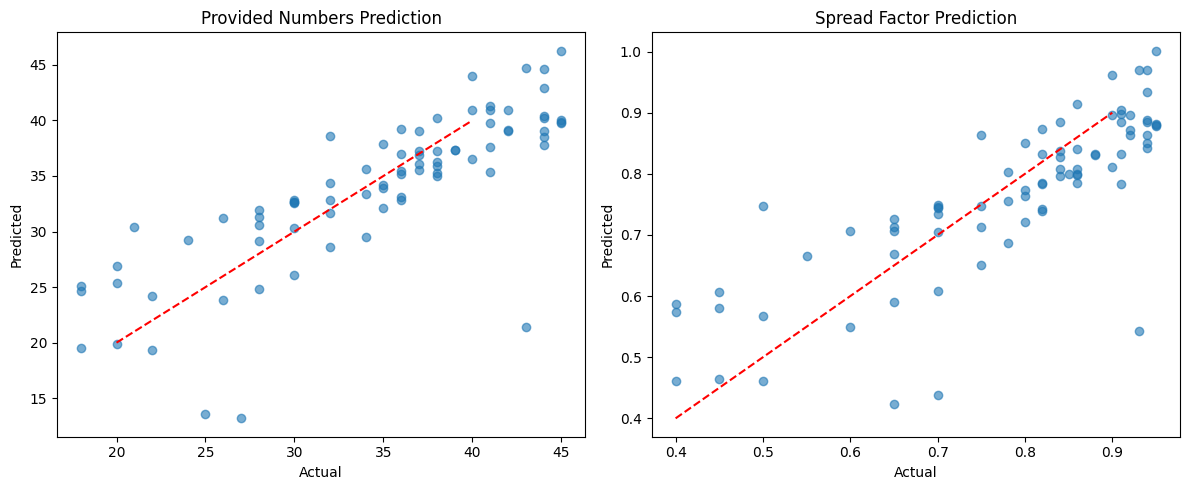

Model saved to models/sudoku_model_fixed.pkl

Example Prediction:
Predicted clues: 18
Predicted spread: 0.53


In [1]:
# %% [markdown]
# # Sudoku Difficulty Predictor - Fixed Version
# With proper array dimensionality handling

# %%
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import joblib
from pathlib import Path
import matplotlib.pyplot as plt

np.random.seed(42)

# %% [markdown]
# ## 1. Data Loading & Cleaning

# %%
def load_and_clean_data(path):
    """Load and clean data with proper NaN handling"""
    df = pd.read_csv(path)
    
    # Create features safely
    df['time_per_move'] = df['completion_time'] / (df['moves'] + 1e-6)  # Prevent division by zero
    df['mistake_rate'] = df['mistakes'] / (df['completion_time'] + 1e-6)
    df['hint_rate'] = df['hints_used'] / (df['completion_time'] + 1e-6)
    
    # Remove extreme outliers
    for col in ['completion_time', 'mistakes', 'hints_used', 'moves']:
        q1 = df[col].quantile(0.01)
        q99 = df[col].quantile(0.99)
        df = df[(df[col] >= q1) & (df[col] <= q99)]
    
    return df

data = load_and_clean_data("/Users/stalinjosephbaguio/Desktop/merge/model /data/combineddata.csv")
print("Clean data shape:", data.shape)
data.head()

# %% [markdown]
# ## 2. Feature Engineering

# %%
# Define features and targets
features = [
    'completion_time',
    'mistakes',
    'hints_used',
    'moves',
    'time_per_move',
    'mistake_rate',
    'hint_rate'
]
targets = ['provided_numbers', 'spread_factor']

# Handle missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(data[features])
y = data[targets].values  # This will be 2D: (n_samples, 2)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# %% [markdown]
# ## 3. Model Training (Fixed Dimensionality)

# %%
# Train separate models for each target
clues_model = LinearRegression()
spread_model = LinearRegression()

# Fit models using proper array indexing
clues_model.fit(X_train_scaled, y_train[:, 0])  # First column: provided_numbers
spread_model.fit(X_train_scaled, y_train[:, 1])  # Second column: spread_factor

# Cross-validation
def print_cv_scores(model, X, y, name):
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
    print(f"{name} CV MAE: {-scores.mean():.2f} ± {scores.std():.2f}")

print_cv_scores(clues_model, X_train_scaled, y_train[:, 0], "Clues")
print_cv_scores(spread_model, X_train_scaled, y_train[:, 1], "Spread")

# %% [markdown]
# ## 4. Evaluation

# %%
def evaluate_model(model, X, y_true, name):
    y_pred = model.predict(X)
    print(f"\n{name} Performance:")
    print(f"MSE: {mean_squared_error(y_true, y_pred):.2f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"R²: {r2_score(y_true, y_pred):.2f}")
    return y_pred

print("=== Training Set ===")
train_clues_pred = evaluate_model(clues_model, X_train_scaled, y_train[:, 0], "Clues")
train_spread_pred = evaluate_model(spread_model, X_train_scaled, y_train[:, 1], "Spread")

print("\n=== Test Set ===")
test_clues_pred = evaluate_model(clues_model, X_test_scaled, y_test[:, 0], "Clues")
test_spread_pred = evaluate_model(spread_model, X_test_scaled, y_test[:, 1], "Spread")

# %% [markdown]
# ## 5. Visualization

# %%
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test[:, 0], test_clues_pred, alpha=0.6)
plt.plot([20, 40], [20, 40], 'r--')
plt.title("Provided Numbers Prediction")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(1, 2, 2)
plt.scatter(y_test[:, 1], test_spread_pred, alpha=0.6)
plt.plot([0.4, 0.9], [0.4, 0.9], 'r--')
plt.title("Spread Factor Prediction")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 6. Model Saving

# %%
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

joblib.dump({
    'clues_model': clues_model,
    'spread_model': spread_model,
    'scaler': scaler,
    'imputer': imputer,
    'features': features
}, model_dir / "sudoku_model_fixed.pkl")

print(f"Model saved to {model_dir/'sudoku_model_fixed.pkl'}")

# %% [markdown]
# ## 7. Example Usage

# %%
sample_stats = {
    'completion_time': 1200,
    'mistakes': 3,
    'hints_used': 5,
    'moves': 45,
    'time_per_move': 1200/45,
    'mistake_rate': 3/1200,
    'hint_rate': 5/1200
}

# Prepare input
sample_df = pd.DataFrame([sample_stats], columns=features)
sample_clean = imputer.transform(sample_df)
sample_scaled = scaler.transform(sample_clean)

# Predict
print("\nExample Prediction:")
print(f"Predicted clues: {int(clues_model.predict(sample_scaled)[0])}")
print(f"Predicted spread: {spread_model.predict(sample_scaled)[0]:.2f}")